A carregar os seus mapas e séries temporais...
A cruzar os edifícios com as suas 101 áreas mistas...

A desenhar o mapa de viabilidade real...


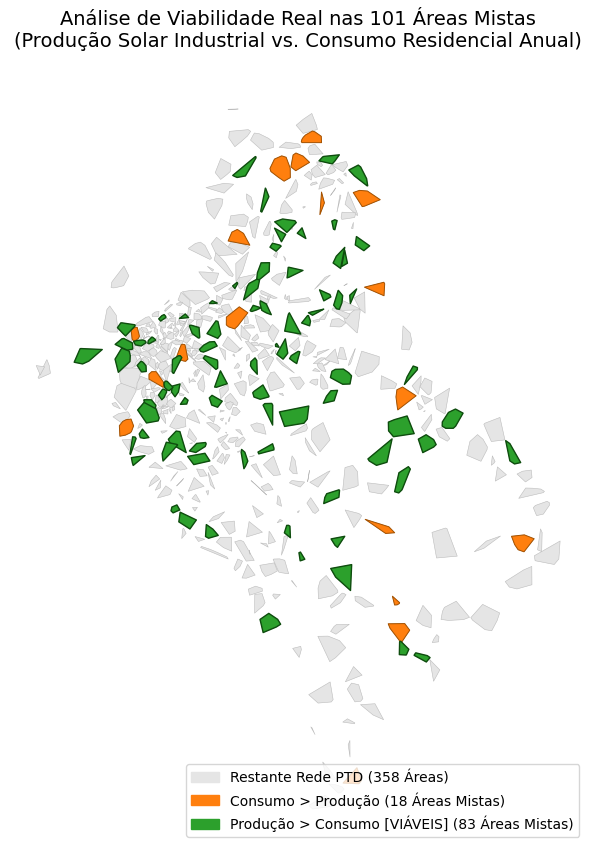

Estatísticas de Conclusão:
 -> Total de áreas mistas analisadas: 101
 -> ÁREAS MISTAS VIÁVEIS REAIS ENCONTRADAS: 83
 -> Áreas mistas deficitárias: 18


In [10]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.ops import transform

# Função de segurança para projetar geometrias 3D para 2D
def forcar_2d(geom):
    if geom and geom.has_z:
        return transform(lambda x, y, z=None: (x, y), geom)
    return geom

# ==============================================================================
# 1. CARREGAR OS DADOS (FILTRADOS E SÉRIES TEMPORAIS)
# ==============================================================================
print("A carregar os seus mapas e séries temporais...")
# USANDO O SEU FICHEIRO FIXO DE 101 ÁREAS MISTAS
areas_mistas = gpd.read_file("PTD_Areas_Mistas_Permanente_Industrial.gpkg")
areas_totais_rede = gpd.read_file("PTD_Areas_Servico_Rede.gpkg")
edificios = gpd.read_file("MstCSCS_Com_Tipologias.gpkg")

df_consumo = pd.read_csv('consumo_anual_estimado_2024.csv', sep=';')
df_producao = pd.read_csv('Serie_Temporal_Producao_Solar_450W_0.86.csv')

# ==============================================================================
# 2. CALCULAR PARÂMETROS ENERGÉTICOS DOS CSVs
# ==============================================================================
total_consumo_kWh = df_consumo['Energia ativa (kWh)'].sum()

df_producao['time'] = pd.to_datetime(df_producao['time'])
num_anos = len(df_producao['time'].dt.year.unique())
prod_anual_por_painel = df_producao['Energy_kWh'].sum() / num_anos
prod_anual_por_m2 = prod_anual_por_painel / 2.0  # 1 painel de 450W por cada 2m2 de telhado

# ==============================================================================
# 3. UNIÃO ESPACIAL FOCADA APENAS NAS 101 ÁREAS MISTAS
# ==============================================================================
if areas_mistas.crs is None: areas_mistas = areas_mistas.set_crs("EPSG:3763")
if edificios.crs is None: edificios = edificios.set_crs("EPSG:3763")
if areas_totais_rede.crs is None: areas_totais_rede = areas_totais_rede.set_crs("EPSG:3763")

if edificios.crs != areas_mistas.crs: edificios = edificios.to_crs(areas_mistas.crs)
if areas_totais_rede.crs != areas_mistas.crs: areas_totais_rede = areas_totais_rede.to_crs(areas_mistas.crs)

edificios['geometry'] = edificios['geometry'].apply(forcar_2d)

# Área global residencial (indispensável para o cálculo proporcional do consumo)
total_area_residencial_global = edificios[edificios['Layer_left'] == 'ED08_EDIF_PERMANENTE']['area_m2'].sum()

print("A cruzar os edifícios com as suas 101 áreas mistas...")
join_mistas = gpd.sjoin(edificios, areas_mistas, how="inner", predicate="intersects")

# Agrupar as áreas construídas por cada um dos PTDs do seu ficheiro
areas_por_ptd = join_mistas.groupby(['ptd_id', 'Layer_left'])['area_m2'].sum().unstack(fill_value=0)

# Calcular balanço energético focado nas suas áreas
areas_por_ptd['Consumo_Anual_kWh'] = (areas_por_ptd['ED08_EDIF_PERMANENTE'] / total_area_residencial_global) * total_consumo_kWh
areas_por_ptd['Producao_Anual_kWh'] = areas_por_ptd['ED06_EDIF_INDUSTRIAL'] * prod_anual_por_m2
areas_por_ptd['Producao_Superior'] = areas_por_ptd['Producao_Anual_kWh'] > areas_por_ptd['Consumo_Anual_kWh']

# ==============================================================================
# 4. RENDERIZAR O MAPA DE VIABILIDADE
# ==============================================================================
areas_mistas_mapeadas = areas_mistas.merge(areas_por_ptd['Producao_Superior'], on='ptd_id', how='left')
areas_mistas_mapeadas['Producao_Superior'] = areas_mistas_mapeadas['Producao_Superior'].fillna(False)

print("\nA desenhar o mapa de viabilidade real...")
fig, ax = plt.subplots(figsize=(12, 10))

# Fundo: Toda a rede de PTDs em cinzento claro
areas_totais_rede.plot(ax=ax, color='#e5e5e5', edgecolor='#bcbcbc', linewidth=0.4)

# Áreas Mistas onde o Consumo domina (Laranja)
areas_mistas_mapeadas[areas_mistas_mapeadas['Producao_Superior'] == False].plot(
    ax=ax, color='#ff7f0e', edgecolor='#a55200', linewidth=0.7
)

# Áreas Mistas VIÁVEIS onde a Produção Solar vence (Verde)
areas_mistas_mapeadas[areas_mistas_mapeadas['Producao_Superior'] == True].plot(
    ax=ax, color='#2ca02c', edgecolor='#0e4d0e', linewidth=1.0
)

# Legenda Científica
num_viaveis = areas_mistas_mapeadas['Producao_Superior'].sum()
num_nao_viaveis = len(areas_mistas_mapeadas) - num_viaveis

plt.title("Análise de Viabilidade Real nas 101 Áreas Mistas\n(Produção Solar Industrial vs. Consumo Residencial Anual)", fontsize=14, pad=20)

patch_rede = mpatches.Patch(color='#e5e5e5', label=f"Restante Rede PTD ({len(areas_totais_rede) - 101} Áreas)")
patch_consumo = mpatches.Patch(color='#ff7f0e', label=f"Consumo > Produção ({num_nao_viaveis} Áreas Mistas)")
patch_producao = mpatches.Patch(color='#2ca02c', label=f"Produção > Consumo [VIÁVEIS] ({num_viaveis} Áreas Mistas)")
plt.legend(handles=[patch_rede, patch_consumo, patch_producao], loc='lower right', fontsize=10)

ax.set_axis_off()
plt.savefig("mapa_balanco_mistas_reais.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Estatísticas de Conclusão:")
print(f" -> Total de áreas mistas analisadas: {len(areas_mistas_mapeadas)}")
print(f" -> ÁREAS MISTAS VIÁVEIS REAIS ENCONTRADAS: {num_viaveis}")
print(f" -> Áreas mistas deficitárias: {num_nao_viaveis}")